# Exploratory data analysis: Telco Customer Churn

Goal: understand who churns before building models. Questions I want to answer:

1. How imbalanced is the target?
2. Which columns need cleaning?
3. How do contract type, tenure, charges and payment method relate to churn?
4. Do the engineered features (tenure buckets, charges per month of tenure, number of services) separate churners from non-churners?

The dataset must be in `data/` first (see `data/README.md`).

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from churn import config
from churn.data import clean, load_raw
from churn.features import add_features

sns.set_theme(style="whitegrid")
raw = load_raw(config.RAW_DATA_PATH)
raw.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Shape, types and missing values

`TotalCharges` is read as text. The blank values belong to customers with `tenure == 0`, who have not been billed yet.

In [2]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:
blank_total = raw["TotalCharges"].str.strip() == ""
print("Blank TotalCharges:", blank_total.sum())
raw.loc[blank_total, ["tenure", "MonthlyCharges", "TotalCharges"]]

Blank TotalCharges: 11


,tenure,MonthlyCharges,TotalCharges
488,0,52.55,
753,0,20.25,
936,0,80.85,
1082,0,25.75,
1340,0,56.05,
3331,0,19.85,
3826,0,25.35,
4380,0,20.00,
5218,0,19.70,
6670,0,73.35,


## 2. Target balance

Churners are a minority, so accuracy alone is misleading: a model that predicts "no churn" for everyone already gets a high accuracy. This is why F1 on the churn class is the main metric.

In [4]:
df = add_features(clean(raw))
df["Churn"].value_counts(normalize=True).rename("share")

Churn
0    0.73463
1    0.26537
Name: share, dtype: float64

**Finding.** 26.5% of the 7,043 customers churned (1,869) and 73.5% stayed. Predicting "no churn" for everyone already scores 73.5% accuracy, which is the baseline the model has to beat.

## 3. Churn rate by categorical drivers

In [5]:
def churn_rate(column: str) -> pd.Series:
    return df.groupby(column)["Churn"].mean().sort_values(ascending=False)

drivers = [
    "Contract", "PaymentMethod", "InternetService",
    "TechSupport", "PaperlessBilling", "SeniorCitizen",
]
for column in drivers:
    print(churn_rate(column).round(3), end="\n\n")

Contract
Month-to-month    0.427
One year          0.113
Two year          0.028
Name: Churn, dtype: float64

PaymentMethod
Electronic check             0.453
Mailed check                 0.191
Bank transfer (automatic)    0.167
Credit card (automatic)      0.152
Name: Churn, dtype: float64

InternetService
Fiber optic    0.419
DSL            0.190
No             0.074
Name: Churn, dtype: float64

TechSupport
No                     0.416
Yes                    0.152
No internet service    0.074
Name: Churn, dtype: float64

PaperlessBilling
Yes    0.336
No     0.163
Name: Churn, dtype: float64

SeniorCitizen
Yes    0.417
No     0.236
Name: Churn, dtype: float64



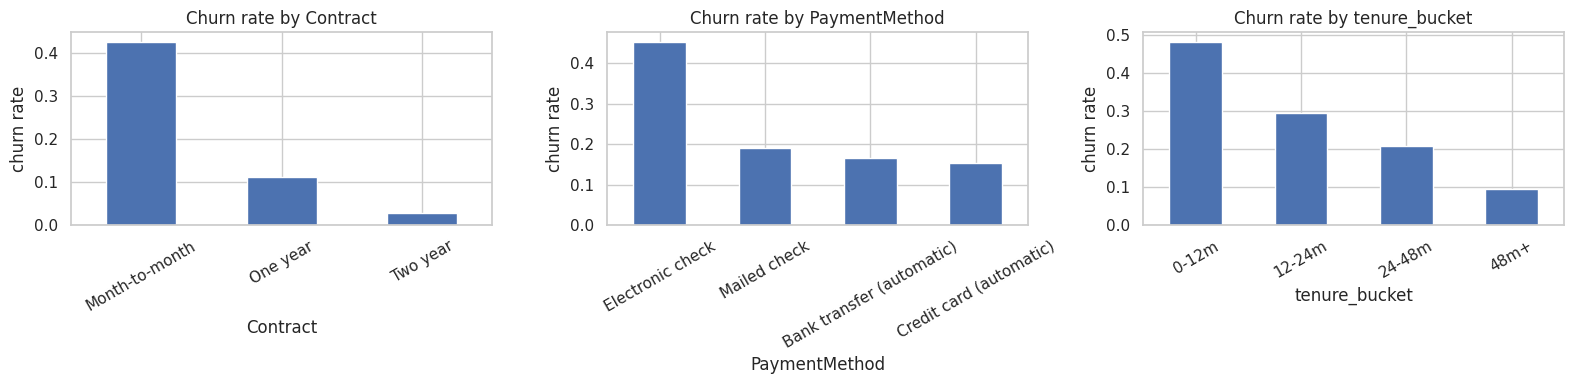

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, column in zip(axes, ["Contract", "PaymentMethod", "tenure_bucket"]):
    churn_rate(column).plot.bar(ax=ax, title=f"Churn rate by {column}")
    ax.set_ylabel("churn rate")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()

**Findings.**

- Contract is the strongest driver: 42.7% churn on month-to-month, 11.3% on one-year and 2.8% on two-year contracts.
- Electronic check payers churn at 45.3%, against 15-19% for the other three payment methods.
- Fiber optic customers churn at 41.9%, DSL at 19.0%, customers without internet at 7.4%. Customers without tech support churn at 41.6% vs 15.2% with it.
- Senior citizens (41.7% vs 23.6%) and paperless billing (33.6% vs 16.3%) also churn more.
- Churn falls steadily with tenure: 48.3% in the first year, 29.5% in year two, 20.9% at 24-48 months and 9.6% after 48 months.

## 4. Numeric features

Compare the distributions of tenure and charges for churners and non-churners.

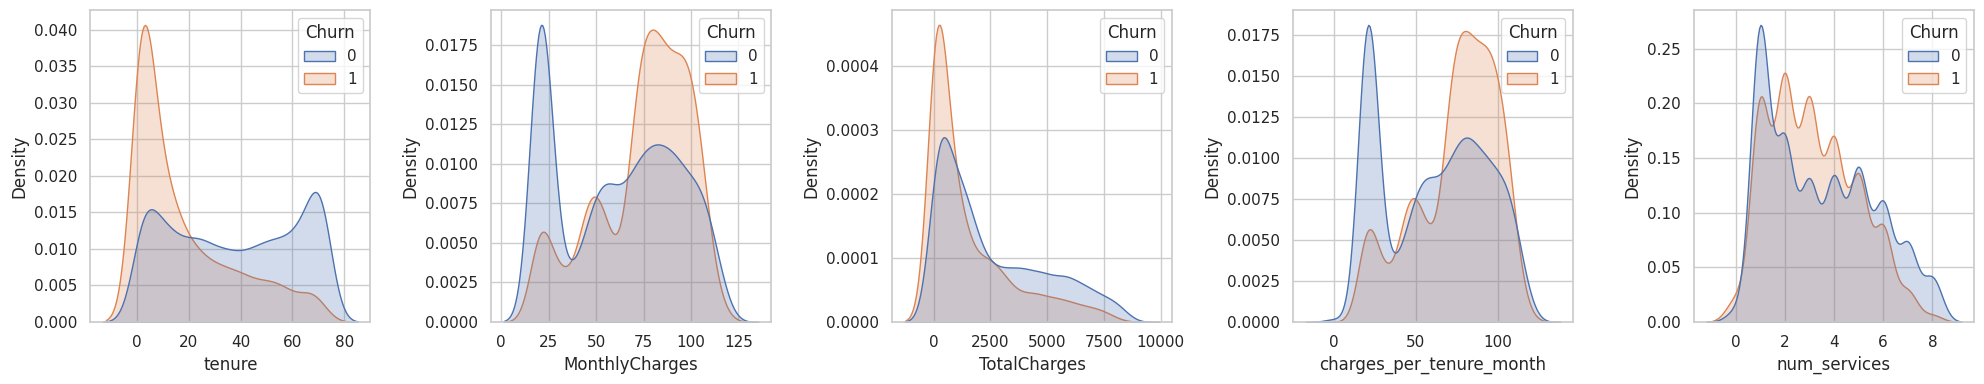

In [7]:
numeric = ["tenure", "MonthlyCharges", "TotalCharges", "charges_per_tenure_month", "num_services"]
fig, axes = plt.subplots(1, len(numeric), figsize=(20, 4))
for ax, column in zip(axes, numeric):
    sns.kdeplot(data=df, x=column, hue="Churn", common_norm=False, fill=True, ax=ax)
plt.tight_layout()

In [8]:
df[numeric + ["contract_months", "Churn"]].corr()["Churn"].sort_values()

contract_months            -0.394453
tenure                     -0.352229
TotalCharges               -0.198324
num_services               -0.067264
charges_per_tenure_month    0.193301
MonthlyCharges              0.193356
Churn                       1.000000
Name: Churn, dtype: float64

**Findings.**

- Churners have much shorter tenure (median 10 months vs 38 for customers who stayed); `contract_months` (-0.39) and `tenure` (-0.35) have the strongest linear correlations with churn.
- Higher monthly charges go with more churn (+0.19), while `TotalCharges` is negative (-0.20) because it is mostly a proxy for tenure (correlation 0.83 with tenure).
- `charges_per_tenure_month` turns out to be almost the same as `MonthlyCharges` (correlation 0.99), so it adds little new information; I kept it because it is cheap, but it is not a strong feature on its own.
- `num_services` is only weakly related to churn (-0.07).

## Notes for modelling

What the outputs above show, and how it is used in `src/churn/features.py` and `src/churn/train.py`:

- churn is concentrated in month-to-month contracts and in the first year of tenure, hence `contract_months` and `tenure_bucket`;
- electronic check payers and fiber optic customers churn more, and automatic payment is captured by `auto_payment`;
- `TotalCharges` mostly duplicates tenure and `charges_per_tenure_month` mostly duplicates `MonthlyCharges`, so tree models are not expected to gain much from these two;
- the target is imbalanced (26.5% churn), so models use class weights, the decision threshold is tuned for F1 on out-of-fold predictions, and accuracy is always compared to the 73.5% majority baseline.